<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°3

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras.datasets.mnist as mnist

# a) Exploración de datos

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, "\n",  y_train.shape, "\n", x_test.shape, "\n", y_test.shape)

print(type(x_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) 
 (60000,) 
 (10000, 28, 28) 
 (10000,)
<class 'numpy.ndarray'>


x_train es un array de numpy cin 60.000 elementos, cada uno de los cuales es una imagen en escala de grises de 28x28 pixeles. Los valores van de 0 a 255

y_train tiene los números que corresponden a cada imagen

In [3]:
#Grafico 10 numeros al azar
indices = np.random.randint(low = 0, high = len(y_train), size = 10)
imagenes = x_train[indices]
numeros = y_train[indices]

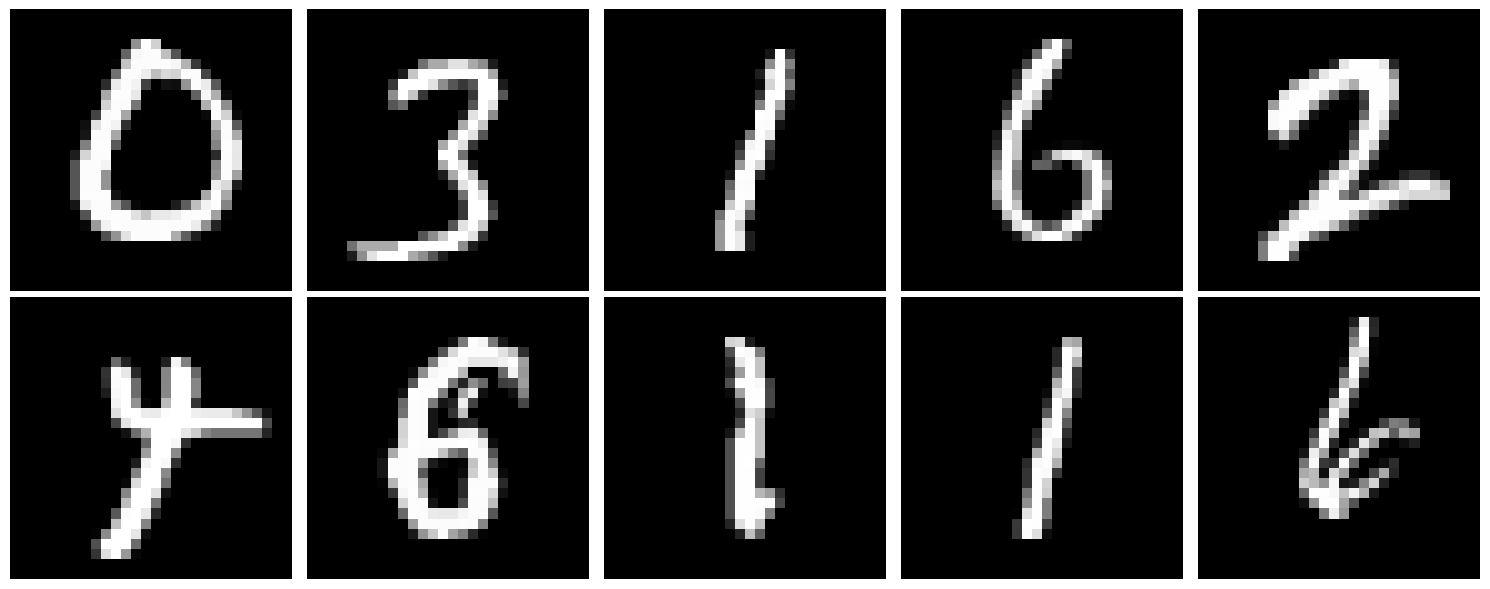

[0 3 1 6 2 4 6 1 1 6]


In [4]:
figs, ejes = plt.subplots(nrows = 2, ncols = 5, figsize = (15, 6))
#nota: ejes es una matriz de 2x5. Cada elemento es una clase llamada Axes

for i, eje in enumerate(ejes.flat):
  eje.imshow(imagenes[i], cmap = "gray")
  #eje.set_title(numeros[i])
  eje.axis("off")

plt.tight_layout()
plt.show()

print(numeros)

In [6]:
#Genero las etiquetas
y_train_etiquetas = y_train%2
y_test_etiquetas = y_test%2


# b) Preprocesamiento

In [7]:
class Normalizar:
  # Opcional, para inicializar atributos o declarar hiperpar´ametros
  def __init__(self):
    self.media = None
    self.desvio = None
    self.mascara = None
    return None

  # Etapa de entrenamiento
  def fit(self,X):
    self.media = np.mean(X, axis = 0) #media a lo largo de las 60.000 imágenes (matriz de 28x28). Valor medio de cada pixel
    self.desvio = np.std(X, axis = 0) #desvio a lo largo de las 60.000 imágenes (matriz de 28x28). Valor de desviación de cada pixel
    self.mascara = self.desvio != 0
    self.media = self.media[self.mascara] #esto hace que sea un array de (717, ). De los 784 pixeles en cada imagen (28x28) solo 717 contienen información util
    self.desvio = self.desvio[self.mascara] #esto hace que sea un array de (717, )
    return None

  # Aplicar la transformación
  def transform(self,X):
    #nota: esta función no debe ser llamada antes de fit(X)

    X_normalizado = (X[:, self.mascara] - self.media) / self.desvio
    #Nota: X[:, self.mascara] convierte las 60.000 matrices de 28x28 en una tira de pixeles de 717 elementos.
    #De esta forma, la salida de la normalización es 60.000 tiras de 717 pixeles cada una
    return X_normalizado

  # Entrenar y aplicar la transformación
  def fit_transform(self,X):
    self.fit(X)
    return self.transform(X)

In [8]:
normalizador = Normalizar()
x_train_norm = normalizador.fit_transform(x_train)
x_test_norm = normalizador.transform(x_test)

# c) Análisis teórico (completar)

1)
La función sigmoide se define como:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

Despejando z de esta definición se hallará la función inversa.

Reagrupo:
$$
1+e^{-z} = \frac{1}{\sigma(z)}
$$

Resto 1 miembro a miembro y aplico el logaritmo natural

$$
-z = \ln(\frac{1-\sigma(z)}{\sigma(z)})
$$

Multiplico miembro a miembro por $-1$ y aplico propiedades del logaritmo. Finalmente:

$$
\sigma^{-1}(z) = \ln(\frac{z}{1-z})
$$

2)
La derivada de $\sigma(z)$ se calculará usando la regla del cociente.

$$
\sigma'(z) = \frac{0\cdot (1+e^{-z}) - 1\cdot(-e^{-z})}{(1+e^{-z})^2} = \frac{e^{-z}}{(1+e^{-z})^2}
$$

Sumando y restando un $1$ en el numerador de esta expresión se puede simplificar el resultado

$$
\sigma'(z) = \frac{1+e^{-z}}{(1+e^{-z})^2} - \frac{1}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} - \frac{1}{(1+e^{-z})^2} = \sigma(z) - \sigma^2(z)
$$

Finalmente:
$$
\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))
$$

3)
El error empírico es

$$
J(w,b) = \frac{1}{n_{tr}} \Sigma_{i = 0} ^{n_{tr}} \ell(x_i, y_i)
$$

donde:

$x_i$ es el i-ésimo predictor o feature

$y_i$ es la i-ésima etiqueta

$n_{tr}$ es la cantidad de muestras y

$\ell(x_i, y_i)$ es la función costo

Para el caso de la regresión lineal o polinómica, $\ell(x_i, y_i)$ era el error cuadrático medio, pero en regresión logística binaria se usa la función log-loss:

$$
\ell(x_i, y_i) = -\log[\hat{P}(y_i|x_i)]
$$

Dado que $y$ es una variable que solo puede tomar 2 valores, su función de masa de probabilidad puede tomar solo 2 valores:

$
\hat{P}(0|x) = 1 - p(x)
$

$
\hat{P}(1|x) = p(x)
$

O, de forma más compacta:

$$
\hat{P}(y|x) = p(x)^{y} \cdot (1 - p(x))^{1-y}
$$

En nuestro caso, estimaremos $p(x)$ (la probabilidad de que $y = 1$) en base al predictor $x$ de la siguiente forma:

$$
p(x) = \sigma(w^T\cdot x + b)
$$

Entonces, $\hat{P}(y|x)$ será:

$$
\hat{P}(y|x) = [\sigma(w^T\cdot x + b)]^{y} \cdot [1 - \sigma(w^T\cdot x + b)]^{1-y}
$$

De esta forma, la función costo es:

$$
\ell(x, y) = -\log(\hat{P}(y|x)) = - (1 - y) \cdot \log[1 - \sigma(w^T\cdot x + b)] -y \cdot \log[\sigma(w^T\cdot x + b)]
$$

Con la función costo expresada de esta forma se puede calcular el gradiente del error, ya que el error es una suma de funciones costo. Por ello, conviene más encontrar las derivadas de la función costo respecto de $w$ y de $b$ para luego calcular las del error.

Por simplicidad se omite el argumento de la función $\sigma(w \cdot x + b)$

$$
\frac{∂\ell}{∂w}(x, y) = - (1-y)\frac{1}{1 - \sigma(\cdot)} \cdot (-1) \cdot \sigma'(\cdot) \cdot x - y \cdot \frac{1}{\sigma(\cdot)} \cdot \sigma'(\cdot) \cdot x = \sigma'(\cdot) \cdot x \cdot[\frac{1-y}{1-\sigma(\cdot)} - \frac{y}{\sigma(\cdot)}] = \sigma(\cdot) \cdot (1- \sigma(\cdot)) \cdot x \cdot [\frac{1-y}{1-\sigma(\cdot)} - \frac{y}{\sigma(\cdot)}] = x \cdot [\sigma(\cdot)(1-y) - (1 - \sigma(\cdot))y] = x \cdot [\sigma(w^T\cdot x + b) - y]
$$

$$
\frac{∂ℓ}{∂b}(x, y) = - (1-y) \frac{1}{1-\sigma(w^T\cdot x + b)}(-1)\sigma'(w^T\cdot x + b) - y \frac{1}{\sigma(w^T\cdot x + b)}\sigma'(w^T \cdot x + b) = \sigma(w^T \cdot x + b) - y
$$

Finalmente, las derivadas del error respecto de $w$ y $b$ son:

$$
\frac{∂J}{∂w} (w, b) = \frac{1}{n_{tr}} \Sigma_{i = 0} ^ {n_{tr} }x_i [\cdot \sigma(w^T\cdot x + b) - y_i]
$$

$$
\frac{∂J}{∂b} (w, b) = \frac{1}{n_{tr}} \Sigma_{i = 0} ^ {n_{tr} } \sigma(w^T \cdot x_i + b) - y_i
$$

# d) Regresión logística

In [13]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

class RegresionLogistica:
  # Opcional, para inicializar atributos o declarar hiperparámetros
  def __init__(self, X, y):
    self.alpha = 0.5
    self.n_iter = 60
    self.error_list = [] #En esta lista guardo el error para cada iteración del gradiente descendente

    self.w = np.zeros(X.shape[1])
    self.b = 0

    self.ntri = len(y)

    self.etiquetas_estimadas = np.zeros(len(y))
    return None

  # Etapa de entrenamiento
  def fit(self,X, y):
    for i in range(self.n_iter):
      #calculo el gradiente para w
      p = sigmoid((np.dot(X, self.w) + self.b))
      err = p - y
      grad_w = (1/self.ntri) * np.dot(X.T, err)
      self.w -= self.alpha * grad_w

      #calculo el gradiente para b
      grad_b = np.mean(err)
      self.b -= self.alpha * grad_b

      #Estimo el error
      self.error_list.append(self.cross_entropy(X, y))
    return None

  # Etapa de testeo soft
  def predict_proba(self,X):
    arg = np.dot(X, self.w) + self.b
    return sigmoid(arg)
    #Nota: esta función da la probabilidad estimada de que la etiqueta sea 1
    #Eso es: estima la probabilidad de que y sea impar basada en la observación de X

  #Decisión Hard
  def predict(self, X):
    probas = self.predict_proba(X)
    self.etiquetas_estimadas = np.where(probas >= 0.5, 1, 0) #predict_proba estima la probabilidad de que y sea 1 (impar)
    #Si probas[i] >= 0.5, lo más probable es que sea impar, así que la decisión hard tiene que ser etiqueta = 1
    return self.etiquetas_estimadas

  # Computar la Cross-Entropy
  def cross_entropy(self,X,y):
    p = self.predict_proba(X)
    return (-1) * np.mean(y*np.log(p) + (1-y)*np.log(1-p))

  # Computar el Accuracy
  def accuracy(self,X,y):
    y_pred = self.predict(X)
    return np.mean(y_pred == y)



In [14]:
reg = RegresionLogistica(x_train_norm, y_train_etiquetas)
reg.fit(x_train_norm, y_train_etiquetas)


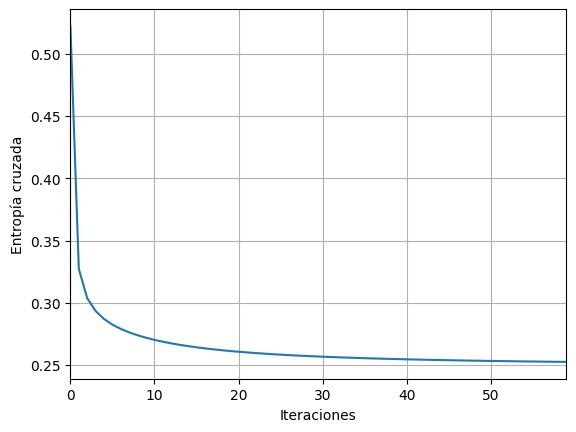

In [15]:
#Grafico del error
plt.plot(reg.error_list)
plt.grid(True)

plt.xlabel("Iteraciones")
plt.xlim(0, reg.n_iter - 1)

plt.ylabel("Entropía cruzada")

plt.show()

In [16]:
CE_entrenamiento = reg.cross_entropy(x_train_norm, y_train_etiquetas)
CE_test = reg.cross_entropy(x_test_norm, y_test_etiquetas)
print("Entropía cruzada de entrenamiento: ", CE_entrenamiento)
print("Entropía cruzada de testeo: ", CE_test)


Entropía cruzada de entrenamiento:  0.25249230748984014
Entropía cruzada de testeo:  0.25649911876520637


In [17]:
Accuracy_entrenamiento = reg.accuracy(x_train_norm, y_train_etiquetas)
Accuracy_testeo = reg.accuracy(x_test_norm, y_test_etiquetas)

print("Accuracy de entrenamiento: ", Accuracy_entrenamiento)
print("Accuracy de testeo: ", Accuracy_testeo)

Accuracy de entrenamiento:  0.9010833333333333
Accuracy de testeo:  0.9007


#e) Curva ROC

In [18]:
#Calculo la curva ROC. Necesito conocer la TPR y la FPR para distintos umbrales
umbrales = np.linspace(0, 1, 100)
TPR = []
FPR = []

probas = reg.predict_proba(x_test_norm)
for umbral in umbrales:
  y_pred = np.where(probas >= umbral, 1, 0)

  #calculo el TPR para este umbral
  true_positive = np.sum((y_pred == 1) & (y_test_etiquetas == 1)) #pone un 1 donde el modelo prediga 1 y el valor real sea 1 (y la suma de eso)
  false_negative = np.sum((y_pred == 0) & (y_test_etiquetas == 1)) #pone un 1 donde el modelo prediga 0 y el valor real sea 1 (y la suma de eso)
  TPR.append(true_positive / (true_positive + false_negative))

  #Calculo el FPR para este umbral
  false_positive = np.sum((y_pred == 1) & (y_test_etiquetas == 0)) #pone un 1 donde el modelo prediga 1 y el valor real sea 0 (y la suma de eso)
  true_negative = np.sum((y_pred == 0) & (y_test_etiquetas == 0)) #pone un 1 donde el modelo prediga 0 y el valor real sea 0 (y la suma de eso)
  FPR.append(false_positive / (false_positive + true_negative))

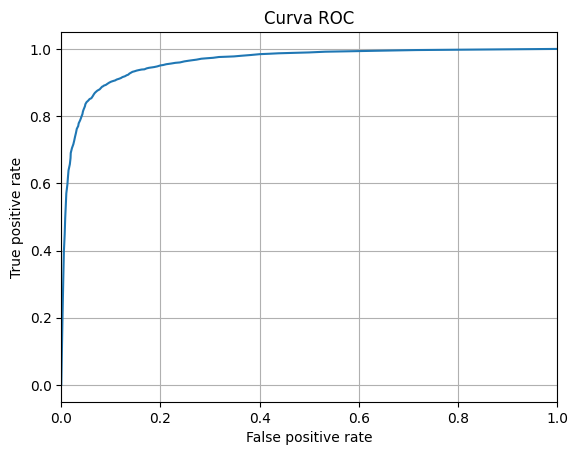

In [19]:
#curva ROC
plt.plot(FPR, TPR)

plt.xlim(0, 1)
plt.xlabel("False positive rate")

plt.ylabel("True positive rate")

plt.title("Curva ROC")

plt.grid(True)

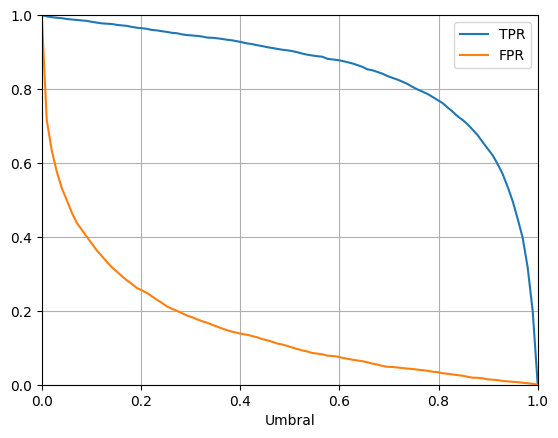

In [20]:
#Cómo varía la TPR con el umbral?
plt.plot(umbrales, TPR, label = 'TPR')

plt.xlim(0, 1)
plt.xlabel("Umbral")

plt.ylim(0, 1)


#Cómo varía la FPR con el umbral?
plt.plot(umbrales, FPR, label = 'FPR')

plt.grid(True)
plt.legend()